# Combo Lock

In [1]:
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np

def get_df_from_train_gen(file: str):
    raw_jl = open(file, 'r', encoding='utf-8').read()

    import json, sys, pathlib

    json_list = []
    for i, raw_json in enumerate(raw_jl.strip().split("\n}")):
        if raw_json.strip():
            json_list.append(json.loads(raw_json + "\n}"))
    df = pd.DataFrame(json_list)
    return df

def get_qualitatives(file, is_sc):
    df = get_df_from_train_gen(file)
    # print(df)
    # just looking for full trajectories
    if is_sc:
        df = pd.DataFrame(df.iloc[0].to_dict())
    else:
        # need to deal with the data in a special way to deduplicate the rewards based on the trajectory ids.
        trajectory_uid_to_some_context = dict()
        indices = []
        for index, (trajectory_uid, step) in enumerate(zip(df.traj_uid[0], df.step[0])):
            if trajectory_uid in trajectory_uid_to_some_context:
                if trajectory_uid_to_some_context[trajectory_uid] < (step, index):
                    trajectory_uid_to_some_context[trajectory_uid] = (step, index) # gets the last step of every trajectory
                continue
            trajectory_uid_to_some_context[trajectory_uid] = (step, index)
        indices = [i for _,i in trajectory_uid_to_some_context.values()]
        df = pd.DataFrame(df.iloc[0].to_dict()).iloc[indices]
    return df


# instantiate tokenizer
from verl.utils import hf_tokenizer
from verl.utils.fs import copy_to_local


local_path = copy_to_local('qwen/qwen2.5-7b-instruct', use_shm=False)
tokenizer = hf_tokenizer(local_path, trust_remote_code=False, is_instruct_model=True)


In [2]:
import re

def get_all_beliefs(trajectory_string):
    actions = trajectory_string.split('Your last action:\n<action>invalid action</action>\nEnvironment feedback:\nCould not parse response')
    belief_matches = []
    for i, action in enumerate(actions):
        action_belief_matches = re.findall(r'(<belief>((?!<belief>).)*?</belief>\n==========)', action, re.DOTALL)
        if len(action_belief_matches) > 1:
            belief_matches.extend(action_belief_matches[:-1]) # remove the last belief, because it came right before an invalid action
    beliefs = [belief[0] for belief in belief_matches]
    return beliefs

def get_all_belief_lens(trajectory_string):
    beliefs = get_all_beliefs(trajectory_string)    
    #belief_lens = [len(belief)-len('<belief></belief>\n==========') for belief in beliefs]
    belief_lens = [len(tokenizer.encode(belief)) for belief in beliefs]
    return belief_lens


# df_beliefs = pd.DataFrame(columns=['checkpoint', 'attempt', 'belief_length'])


step0 = (0, "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__sc_False_belief_prompting_True_inference/train_gen.txt")
ckpts_and_files = [step0] +[(ckpt, f"/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_{ckpt}_inference/train_gen.txt") for ckpt in [20,40,60,80,100,120,140]]

ckpts_and_files_grading = [step0] + [ (ckpt, f"/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworl/grpo_qwen2.5_7b_b128_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_False_belief_prompting_True_BG_2.0combolock_vs_r1_new_parse4/global_step_{ckpt}_sc_False_belief_prompting_True_inference/train_gen.txt") for ckpt in [20,40,60,80,100,120,140] ]

# checkpoints = []
# for ckpt, file in ckpts_and_files_grading:
#     df = get_qualitatives(file, False)
#     checkpoints.append(ckpt)
#     all_belief_lens = df.full_trajectory_strings.apply(get_all_belief_lens)
#     for trajectory in all_belief_lens:
#         for attempt_i, belief_len in enumerate(trajectory):
#             df_beliefs = pd.concat([df_beliefs, pd.DataFrame({'checkpoint': [checkpoints[-1]], 'attempt': [attempt_i+1], 'belief_length': [belief_len]})])

In [4]:
import plotly.graph_objects as go
import plotly.colors as pc

def load_ckpt_beliefs(ckpts_and_files):
    # load files into df_beliefs
    df_beliefs = pd.DataFrame(columns=['checkpoint', 'attempt', 'belief_length'])
    checkpoints = []
    for ckpt, file in ckpts_and_files:
        df = get_qualitatives(file, False)
        checkpoints.append(ckpt)
        all_belief_lens = df.full_trajectory_strings.apply(get_all_belief_lens)
        for trajectory in all_belief_lens:
            for attempt_i, belief_len in enumerate(trajectory):
                df_beliefs = pd.concat([df_beliefs, pd.DataFrame({'checkpoint': [checkpoints[-1]], 'attempt': [attempt_i+1], 'belief_length': [belief_len]})])
    return df_beliefs

def plot_belief_length_over_training(df_beliefs):
    fig = go.Figure()
    colors = pc.sample_colorscale('viridis', [i/7 for i in range(8)])

    for checkpoint_i, color in zip([0, 20, 40, 60, 80, 100, 120, 140], colors):
        mean_df_attempts = df_beliefs[df_beliefs.checkpoint == checkpoint_i].groupby(['attempt'])['belief_length'].agg(['mean', 'std', 'count']).reset_index()
        mean_df_attempts['sem'] = mean_df_attempts['std'] / mean_df_attempts['count'].apply(lambda n: np.sqrt(n) if n > 0 else 1)
        
        # Add main line
        fig.add_trace(go.Scatter(
            x=mean_df_attempts.attempt,
            y=mean_df_attempts['mean'],
            mode='lines',
            name=f'Train step {checkpoint_i}',
            line=dict(color=color),
            showlegend=True
        ))
        # Add shaded region for error bounds
        error_lower = mean_df_attempts['mean'] - mean_df_attempts['sem']
        error_upper = mean_df_attempts['mean'] + mean_df_attempts['sem']
        x = mean_df_attempts.attempt
        # Add the lower error bound trace
        fig.add_trace(go.Scatter(
            x=x,
            y=error_lower,
            mode='lines',
            line=dict(width=0), # Hide the line for the lower bound
            showlegend=False,
            hoverinfo="skip",
            legendgroup=str(checkpoint_i)
        ))

        # Add the upper error bound trace and fill to the lower bound
        fig.add_trace(go.Scatter(
            x=x,
            y=error_upper,
            mode='lines',
            fill='tonexty', # Fill the area between this trace and the previous one
            fillcolor=color.replace('rgb', 'rgba').replace(')', ', 0.2)'),
            line=dict(width=0), # Hide the line for the upper bound
            hoverinfo="skip",
            showlegend=False,
            legendgroup=str(checkpoint_i)
        ))
    
    # Add full history line above the other lines
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, 14),
            y=len(tokenizer.encode("Your last action:\n<action>['h', 'r', 't']</action>\nEnvironment feedback:\nh is not in Position 1, but is in the lock\n\nr is not in the lock\nt is in Position 3!\n"))*np.arange(1, 14),
            mode='lines+markers',
            name='History length',
            legendgroup='history',
            showlegend=True,  # only show legend once
            line=dict(color='gray', width=2, dash='dot'),
            marker=dict(color='gray')
        ))
        
    fig.update_layout(
        xaxis_title='Environment Steps',
        yaxis_title='Mean Belief Length (tokens)',
        xaxis=dict(range=[1, 13], dtick=1, automargin=True),
        yaxis=dict(range=[40, 160]),
        legend=dict(orientation='v', font=dict(size=16)),
        font=dict(family='Times New Roman', size=16, color='black'),
        template='plotly_white',
        width=600,
        height=470,
    )
    fig.show()
    return fig


In [ ]:

df_beliefs = load_ckpt_beliefs(ckpts_and_files)
fig = plot_belief_length_over_training(df_beliefs)
fig.write_image('figures/belief_length_over_training_tokens.pdf', width=600, height=480)

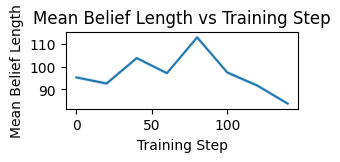

In [84]:
mean_df = df_beliefs.groupby(['checkpoint'])['belief_length'].agg(['mean', 'std', 'count']).reset_index()
mean_df['sem'] = mean_df['std'] / mean_df['count'].apply(lambda n: np.sqrt(n) if n > 0 else 1)
plt.plot(mean_df.checkpoint, mean_df['mean'])
plt.fill_between(mean_df.checkpoint, 
                 (mean_df['mean']-mean_df['sem']).astype(float), 
                 (mean_df['mean']+mean_df['sem']).astype(float), 
                 alpha=0.2)
plt.xlabel('Training Step')
plt.ylabel('Mean Belief Length')
plt.title('Mean Belief Length vs Training Step')
plt.gcf().set_size_inches(3, 1)
plt.show()

In [6]:
df_beliefs_grading = load_ckpt_beliefs(ckpts_and_files_grading)
fig = plot_belief_length_over_training(df_beliefs_grading)
fig.write_image('figures/belief_length_over_training_tokens_grading.pdf', width=600, height=480)

In [8]:
fig.write_image('figures/belief_length_over_training_tokens_grading.pdf', width=600, height=480)

In [85]:
df_0 = get_qualitatives(ckpts_and_files_grading[0][1], False)
df_140 = get_qualitatives(ckpts_and_files_grading[-1][1], False)

beliefs_0 = df_0.full_trajectory_strings.apply(get_all_beliefs)
beliefs_140 = df_140.full_trajectory_strings.apply(get_all_beliefs)

In [86]:
pprint(beliefs_0.iloc[4])

["<belief>character set: ['a', 's', 'd', 'r', 'f', 't', 'g', 'y', 'h', 'u', "
 "'j', 'i', 'k']\n"
 'positions 1, 2, and 3 must be filled with unique characters from the above '
 'set.\n'
 "no character from the previous query ('q', 'w', 'e') is in the "
 'combination.</belief>\n'
 '==========',
 '<belief>\n'
 "character set: ['s', 'r', 't', 'f', 'y', 'h', 'u', 'j', 'i', 'k']\n"
 'positions 1 and 2 must be filled with unique characters from the above set.\n'
 "The character 'g' is in Position 3.\n"
 "Characters 'a' and 'd' are not in the lock.\n"
 '</belief>\n'
 '==========',
 "<belief>character set: ['t', 'f', 'y', 'h', 'u', 'j', 'i', 'k']\n"
 'positions 1 and 2 must be filled with unique characters from the above set.\n'
 "character 'g' is in position 3.\n"
 "characters 'a', 'd', 's', and 'r' are not in the lock.</belief>\n"
 '==========']


In [87]:
pprint(beliefs_140.iloc[3])

["<belief>Characters ['a', 's', 'd', 'r', 'f', 't', 'g', 'y', 'h', 'u', 'j', "
 "'i', 'k'] are possible. 'q', 'w', 'e' are not in the combination. The "
 'correct combination is a unique arrangement of three characters from the '
 'remaining set.</belief>\n'
 '==========',
 "<belief>characters ['r', 'f', 't', 'g', 'y', 'h', 'u', 'j', 'i', 'k'] are "
 "possible. 'q', 'w', 'e', 'a', 's', 'd' are not in the combination. the "
 'correct combination is a unique arrangement of three characters from the '
 'remaining set.</belief>\n'
 '==========',
 "<belief>characters ['f', 'g', 'y', 'h', 'u', 'j', 'i', 'k'] are possible. "
 "'r', 't', 'q', 'w', 'e', 'a', 's', 'd' are not in the combination. 'f' is in "
 'the lock but not in Position 2, meaning it is either in Position 1 or '
 'Position 3. The correct combination is a unique arrangement of three '
 'characters from the remaining set.</belief>\n'
 '==========',
 "<belief>Since 'f' is in Position 1, the combination starts with 'f'. The "
 "cha

In [6]:
df_0 = get_qualitatives(ckpts_and_files_grading[0][1], False)


In [9]:
print(df_0.iloc[0].full_trajectory_strings)

system
You will determine the correct combination of characters at [Position 1, Position 2, Position 3] in a 3-character combination lock through iterative reasoning and queries.
All 3 characters are unique.
The set of valid characters are as follows: ['q', 'a', 'w', 's', 'e', 'd', 'r', 'f', 't', 'g', 'y', 'h', 'u', 'j', 'i', 'k']
Each action is a query of the form ['char 1', 'char 2', 'char 3'].
Each time you query a combination, you will get feedback from the user about each character: either not in the combination, in the combination but in a different position, or in the combination and in the right position.
You can make up to 16 queries.
Your goal is to find the correct combination in the least number of queries.
user
Give me your first query formatted as a list of 3 characters inside <action> ... </action> after thinking inside <think> ... </think>, e.g., <think> Let's think step by step before giving the query [your extensive thinking] </think> <action>['char 1', 'char 2', 'cha

In [ ]:
# Plotly version of the chart with requested colors and trace order.
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

# Data from the user
X = [0, 20, 40, 60, 80, 100, 120, 140]
X_rev = X[::-1]
def get_line_and_err(data_from_seeds):
    d = np.array(data_from_seeds)
    return d.mean(axis=0).tolist(), (d.mean(axis=0)-d.min(axis=0)).tolist()
vanilla_performance_1 = [41.80, 54, 66, 70, 79, 75.78, 74.2, 71.7]
vanilla_performance_2 = [41.80, 51.563, 57.812, 53.125, 46.875, 69.531, 79.688, 78.125]
belief_prompting_differenent_messages_performance_1 = [45.12, 58, 62.6, 68.75, 67.7, 60.156, 74.8, 78.5]
belief_prompting_differenent_messages_performance_2 = [45.12, 64.06, 67.97, 75, 69.53, 74.22, 68.75, 75.781]
seed_1_ABBEL_data = [21.09, 49.22, 50.78, 60.55, 65.82, 69.14, 69.92, 72.27]
seed_2_ABBEL_data = [21.09, 59.6, 64.45, 65.82, 68.16, 64.26, 65.23, 66.8]
# seed_1_ABBEL_belief_grading_performance_grok = [21.09, 55.47, 80.86, 80.86, 76.95,  82.03,  90.6,  91.79]
# the below are with gemini 3 flash:
seed_1_ABBEL_belief_grading_performance = [21.09, 59.375, 73.438, 80.469, 86.719,  90.625,  91.406,  90.625]
seed_2_ABBEL_belief_grading_performance = [21.09, 42.969, 78.906, 85.938, 85.156,  91.406,  91.406,  78.906]
def standard_error(p, n=512):
    return np.sqrt(p * (100 - p) / n)

# Compute standard errors (percent scale, matching the inputs)
# seed_1_err = [standard_error(p) for p in seed_1_ABBEL_data]
# seed_2_err = [standard_error(p) for p in seed_2_ABBEL_data]
# vanilla_err = [standard_error(p) for p in vanilla_performance]
# belief_err = [standard_error(p) for p in belief_prompting_differenent_messages_performance]
# seed_1_ABBEL_belief_grading_err = [seed_1_err[0]] + [standard_error(p, n=256) for p in seed_1_ABBEL_belief_grading_performance[1:]]

palette = px.colors.qualitative.Dark24
colors = [palette[i] for i in [1, 6, 15, 19, 10]]

fig = go.Figure()
vanilla_performance, vanilla_err = get_line_and_err([vanilla_performance_1, vanilla_performance_2])
belief_prompting_performance, belief_prompting_err = get_line_and_err([belief_prompting_differenent_messages_performance_1, belief_prompting_differenent_messages_performance_2])
abbel_performance, abbel_err = get_line_and_err([seed_1_ABBEL_data, seed_2_ABBEL_data])
abbel_bg_performance, abbel_bg_err = get_line_and_err([seed_1_ABBEL_belief_grading_performance, seed_2_ABBEL_belief_grading_performance])
fig.add_trace(go.Scatter(
    x=X, y=vanilla_performance, mode="lines+markers", name="FULL CTX",
    line=dict(color="rgb(128, 128, 128)", dash='dash'),
    error_y=dict(type="data", array=vanilla_err, visible=True)
))
fig.add_trace(go.Scatter(
    x=X, y=belief_prompting_performance, mode="lines+markers", name="FC BELIEFS",
    line=dict( color="rgb(200, 200, 200)", dash="dash"), marker=dict(symbol="square"),
    error_y=dict(type="data", array=belief_prompting_err, visible=True)
))
fig.add_trace(go.Scatter(
    x=X, y=abbel_performance, mode="lines+markers", name="ABBEL",
    line=dict(color="rgb(100, 168, 112)"),
    error_y=dict(type="data", array=abbel_err, visible=True)
))
fig.add_trace(go.Scatter(
    x=X, y=abbel_bg_performance, mode="lines+markers", name="ABBEL BG",
    line=dict(color="rgb(164, 230, 157)"),
    error_y=dict(type="data", array=abbel_bg_err, visible=True)
))

fig.update_layout(
    # title={'text': "Test Performance Over Training", 'x': 0.5, 'xanchor': 'center'},
    font=dict(family='Times New Roman', size=18, color='black'),
    xaxis_title="Training Step",
    yaxis_title="Test Success Rate (%)",
    xaxis=dict(range=[-5, 145], gridcolor="rgba(0,0,0,0.1)"),
    yaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
    # legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
    width=400,
    height=350,
    # margin=dict(l=60, r=20, t=70, b=60)
)

# Save to files
# html_path = "/mnt/data/success_plot_plotly.html"
# png_path = "/mnt/data/success_plot_plotly.png"
pdf_path = "figures/success_plot.pdf"
# fig.write_html(html_path, include_plotlyjs="cdn")

# Try saving PNG (requires kaleido). Wrap in try/except in case it's not available.
png_saved = True
fig.write_image(pdf_path)

# try:
#     fig.write_image(png_path, scale=2, width=1200, height=700)
# except Exception as e:
#     png_saved = False
#     png_error = repr(e)

# Show the interactive figure in the notebook
fig # , {"html_path": html_path, "png_path": png_path, "png_saved": png_saved}

In [ ]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

# Data from the user
X = [0, 20, 40, 60, 80, 100, 120, 140]
X_rev = X[::-1]
def get_line_and_err(data_from_seeds):
    d = np.array(data_from_seeds)
    return d.mean(axis=0).tolist(), (d.mean(axis=0)-d.min(axis=0)).tolist()
# vanilla_performance_1 = [41.80, 54, 66, 70, 79, 75.78, 74.2, 71.7]
# vanilla_performance_2 = [41.80, 51.563, 57.812, 53.125, 46.875, 69.531, 79.688, 78.125]
# belief_prompting_differenent_messages_performance_1 = [45.12, 58, 62.6, 68.75, 67.7, 60.156, 74.8, 78.5]
# belief_prompting_differenent_messages_performance_2 = [45.12, 64.06, 67.97, 75, 69.53, 74.22, 68.75, 75.781]
# seed_1_ABBEL_data = [21.09, 49.22, 50.78, 60.55, 65.82, 69.14, 69.92, 72.27]
# seed_2_ABBEL_data = [21.09, 59.6, 64.45, 65.82, 68.16, 64.26, 65.23, 66.8]
# # seed_1_ABBEL_belief_grading_performance_grok = [21.09, 55.47, 80.86, 80.86, 76.95,  82.03,  90.6,  91.79]
# # the below are with gemini 3 flash:
# seed_1_ABBEL_belief_grading_performance = [21.09, 59.375, 73.438, 80.469, 86.719,  90.625,  91.406,  90.625]
# seed_2_ABBEL_belief_grading_performance = [21.09, 42.969, 78.906, 85.938, 85.156,  91.406,  91.406,  78.906]

12.75
12.19140625
14.126953125
vanilla_performance_1, vanilla_performance_2 = [[12.75, 11.87890625, 10.6484375, 10.3359375, 9.837890625, 10.12890625, 9.86328125, 9.5390625], [12.75, 12.1875, 11.0625, 10.890625, 12.0546875, 10.2109375, 9.1796875, 9.3984375]]
belief_prompting_differenent_messages_performance_1, belief_prompting_differenent_messages_performance_2 = [[12.19140625, 11.15625, 10.470703125, 10.326171875, 10.00390625, 10.49609375, 9.595703125, 9.31640625], [12.19140625,10.7421875, 10.0234375, 9.796875, 9.546875, 9.2109375, 9.8515625, 8.828125]]
seed_1_ABBEL_data, seed_2_ABBEL_data = [[14.126953125, 12.466796875, 11.990234375, 11.474609375, 10.8984375, 10.8671875, 10.44140625, 10.720703125], [14.126953125, 12.962890625, 12.501953125, 11.2890625, 11.265625, 10.9609375, 11.01171875, 10.896484375]]
seed_1_ABBEL_belief_grading_performance, seed_2_ABBEL_belief_grading_performance =[[14.126953125, 11.765625, 10.3125, 9.5703125, 9.3671875, 8.546875, 8.578125, 8.359375], [14.126953125, 12.1015625, 10.0703125, 8.7890625, 9.4296875, 8.6640625, 8.6796875, 9.921875]]
def standard_error(p, n=512):
    return np.sqrt(p * (100 - p) / n)

# Compute standard errors (percent scale, matching the inputs)
# seed_1_err = [standard_error(p) for p in seed_1_ABBEL_data]
# seed_2_err = [standard_error(p) for p in seed_2_ABBEL_data]
# vanilla_err = [standard_error(p) for p in vanilla_performance]
# belief_err = [standard_error(p) for p in belief_prompting_differenent_messages_performance]
# seed_1_ABBEL_belief_grading_err = [seed_1_err[0]] + [standard_error(p, n=256) for p in seed_1_ABBEL_belief_grading_performance[1:]]

palette = px.colors.qualitative.Dark24
colors = [palette[i] for i in [1, 6, 15, 19, 10]]

fig = go.Figure()
vanilla_performance, vanilla_err = get_line_and_err([vanilla_performance_1, vanilla_performance_2])
belief_prompting_performance, belief_prompting_err = get_line_and_err([belief_prompting_differenent_messages_performance_1, belief_prompting_differenent_messages_performance_2])
abbel_performance, abbel_err = get_line_and_err([seed_1_ABBEL_data, seed_2_ABBEL_data])
abbel_bg_performance, abbel_bg_err = get_line_and_err([seed_1_ABBEL_belief_grading_performance, seed_2_ABBEL_belief_grading_performance])
fig.add_trace(go.Scatter(
    x=X, y=vanilla_performance, mode="lines+markers", name="FULL CTX",
    line=dict(color="rgb(128, 128, 128)", dash='dash'),
    error_y=dict(type="data", array=vanilla_err, visible=True)
))
fig.add_trace(go.Scatter(
    x=X, y=belief_prompting_performance, mode="lines+markers", name="FC BELIEFS",
    line=dict( color="rgb(200, 200, 200)", dash="dash"), marker=dict(symbol="square"),
    error_y=dict(type="data", array=belief_prompting_err, visible=True)
))
fig.add_trace(go.Scatter(
    x=X, y=abbel_performance, mode="lines+markers", name="ABBEL",
    line=dict(color="rgb(100, 168, 112)"),
    error_y=dict(type="data", array=abbel_err, visible=True)
))
fig.add_trace(go.Scatter(
    x=X, y=abbel_bg_performance, mode="lines+markers", name="ABBEL BG",
    line=dict(color="rgb(164, 230, 157)"),
    error_y=dict(type="data", array=abbel_bg_err, visible=True)
))

fig.update_layout(
    # title={'text': "Test Performance Over Training", 'x': 0.5, 'xanchor': 'center'},
    font=dict(family='Times New Roman', size=18, color='black'),
    xaxis_title="Training Step",
    # yaxis_title="Test Success Rate (%)",
    yaxis_title="Cumulative Regret",
    xaxis=dict(range=[-5, 145], gridcolor="rgba(0,0,0,0.1)"),
    yaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
    # legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
    width=400,
    height=350,
    # margin=dict(l=60, r=20, t=70, b=60)
)

# Save to files
# html_path = "/mnt/data/success_plot_plotly.html"
# png_path = "/mnt/data/success_plot_plotly.png"
pdf_path = "figures/regret_plot.pdf"
# fig.write_html(html_path, include_plotlyjs="cdn")

# Try saving PNG (requires kaleido). Wrap in try/except in case it's not available.
png_saved = True
fig.write_image(pdf_path)

# try:
#     fig.write_image(png_path, scale=2, width=1200, height=700)
# except Exception as e:
#     png_saved = False
#     png_error = repr(e)

# Show the interactive figure in the notebook
fig # , {"html_path": html_path, "png_path": png_path, "png_saved": png_saved}